# Employee Attrition and Salary Prediction Using Machine Learning

## Machine Learning Final Project

This project applies different supervised machine learning algorithms on HR data to solve regression and classification problems.

### Regression Models:
- Linear Regression
- Decision Tree Regressor

### Classification Models:
- Logistic Regression
- Decision Tree Classifier
- CatBoost Classifier
- LightGBM Classifier

In [2]:
#!pip install catboost
#!pip install lightgbm
#!pip install XGBoost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

## Loading Dataset

In [4]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Exploratory Data Analysis

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [9]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


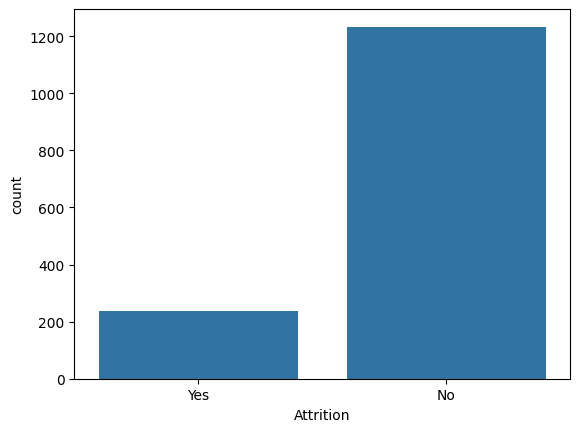

In [10]:
sns.countplot(
    x="Attrition",
    data=df
)

plt.show()

## Data Cleaning

In [11]:
df.drop(["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"], axis=1, inplace=True)

In [12]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [13]:
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,No
freq,1233,1043,961,606,882,326,673,1054


In [14]:
categorical_features = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime"
]

numerical_features = df.columns.difference(categorical_features)
numerical_features = numerical_features.drop(["Attrition", "MonthlyIncome"])
numerical_features

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [16]:
for feature in categorical_features:
    print(f"{feature}: {df[feature].unique()} \n")

BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] 

Department: ['Sales' 'Research & Development' 'Human Resources'] 

EducationField: ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources'] 

Gender: ['Female' 'Male'] 

JobRole: ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources'] 

MaritalStatus: ['Single' 'Married' 'Divorced'] 

OverTime: ['Yes' 'No'] 



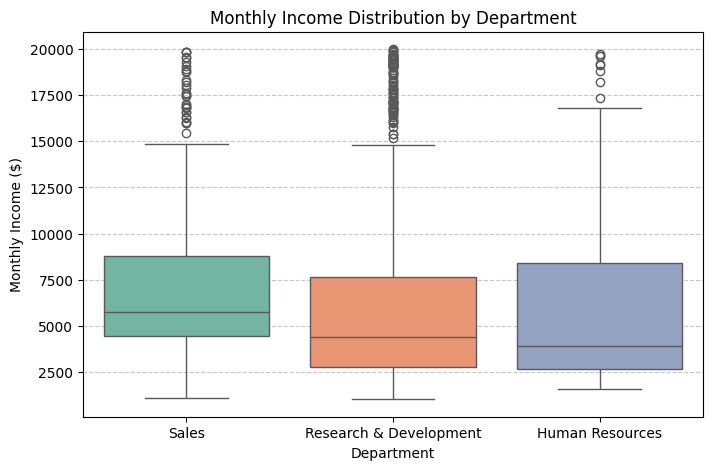

In [17]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Department', y='MonthlyIncome', hue='Department', data=df, palette='Set2', legend=False)
plt.title('Monthly Income Distribution by Department')
plt.xlabel('Department')
plt.ylabel('Monthly Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

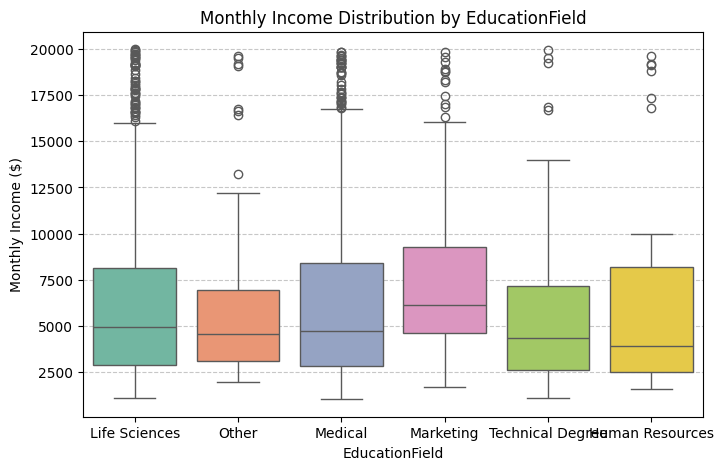

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='EducationField', y='MonthlyIncome', hue='EducationField', data=df, palette='Set2', legend=False)
plt.title('Monthly Income Distribution by EducationField')
plt.xlabel('EducationField')
plt.ylabel('Monthly Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

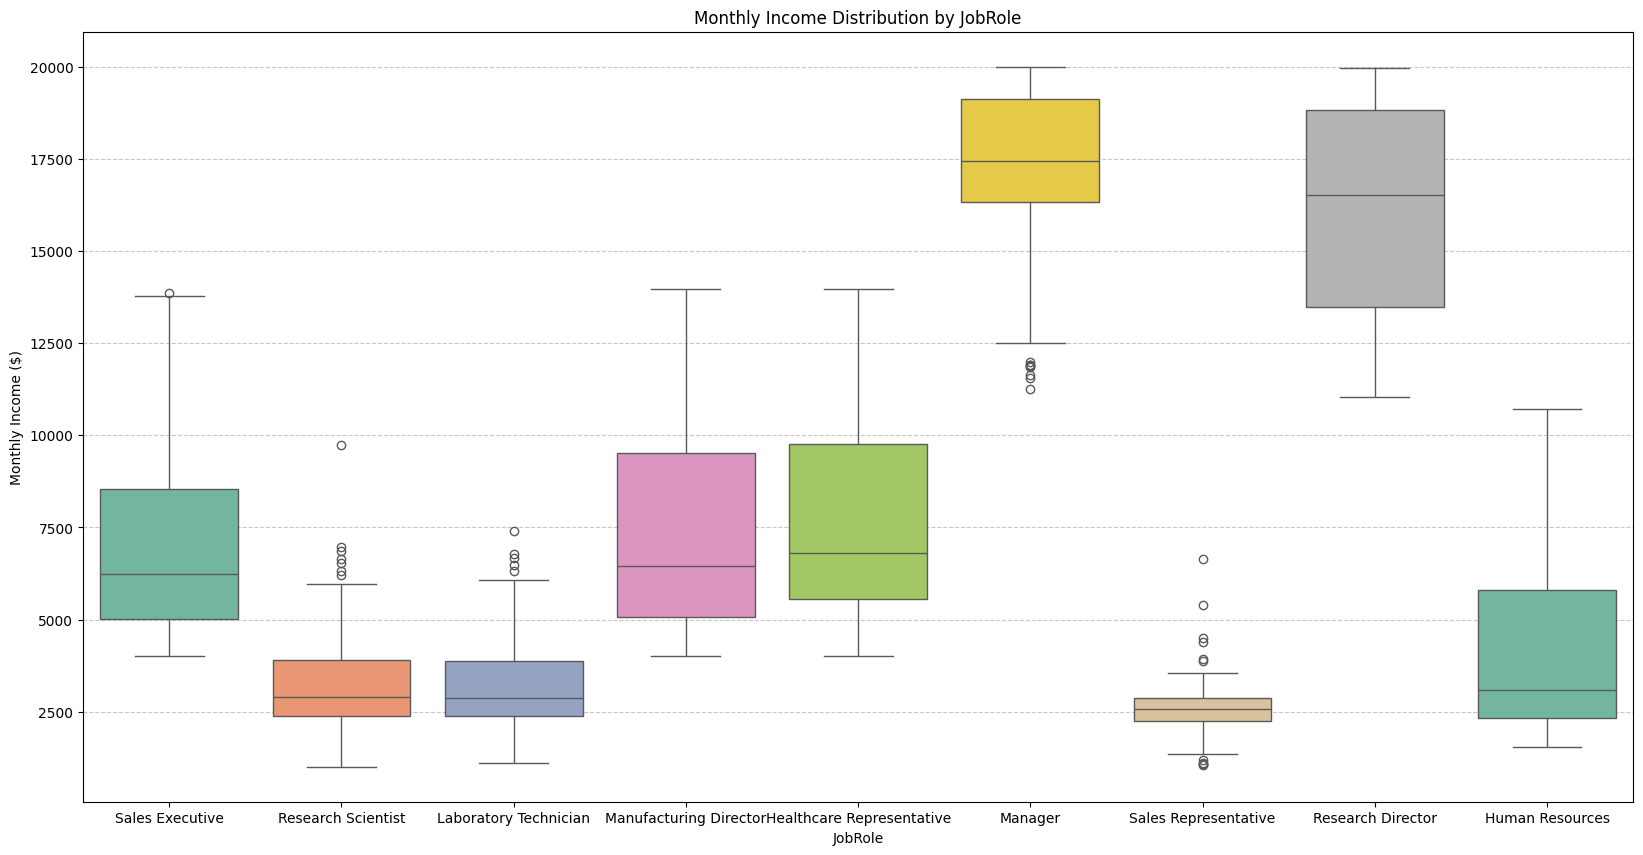

In [19]:
plt.figure(figsize=(20, 10))
sns.boxplot(x='JobRole', y='MonthlyIncome', hue='JobRole', data=df, palette='Set2', legend=False)
plt.title('Monthly Income Distribution by JobRole')
plt.xlabel('JobRole')
plt.ylabel('Monthly Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Outliters

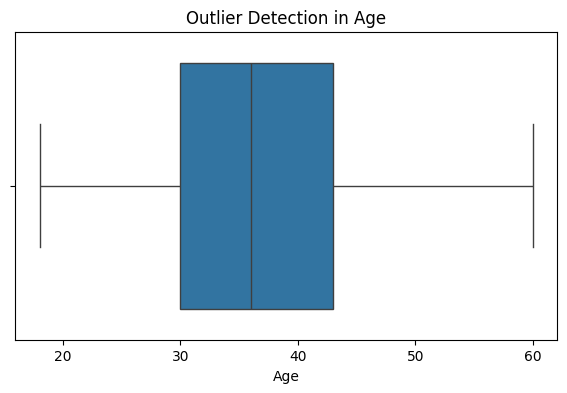

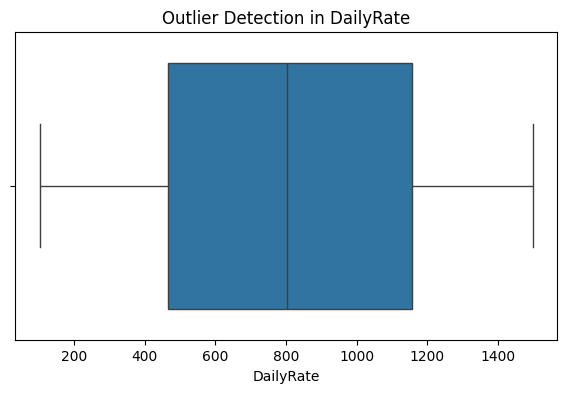

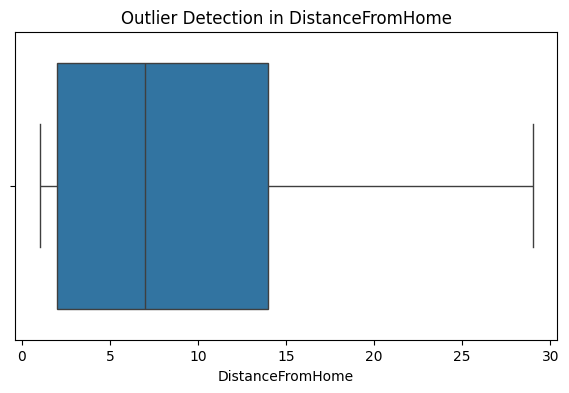

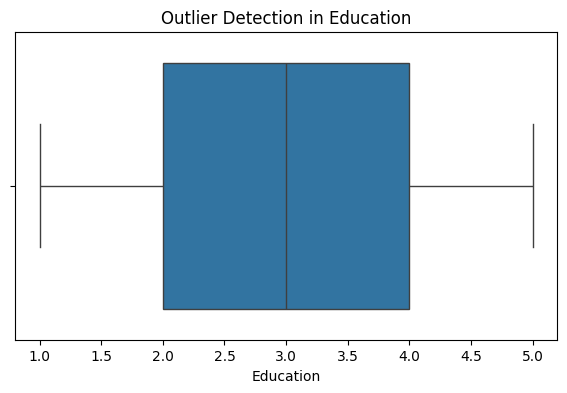

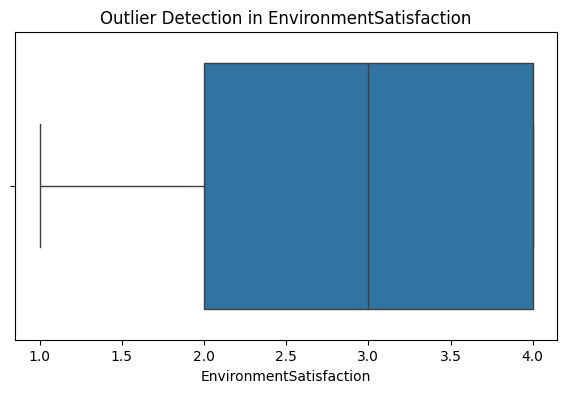

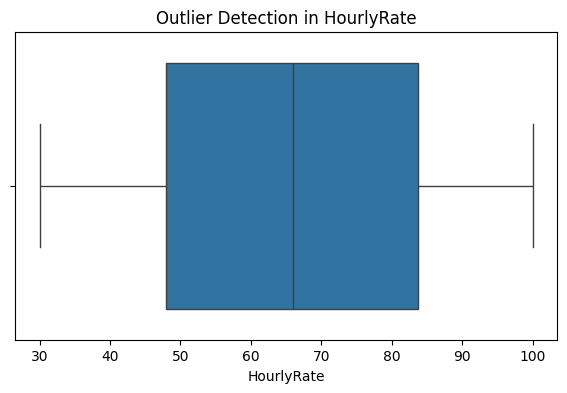

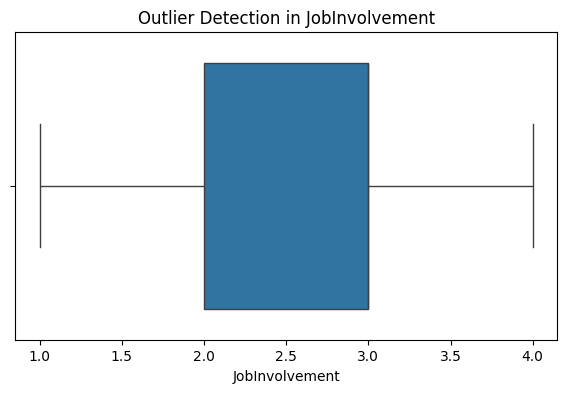

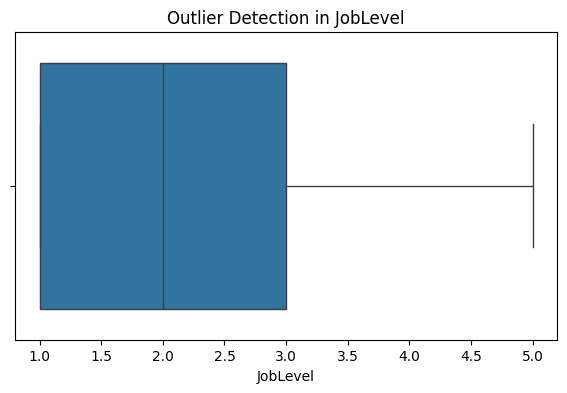

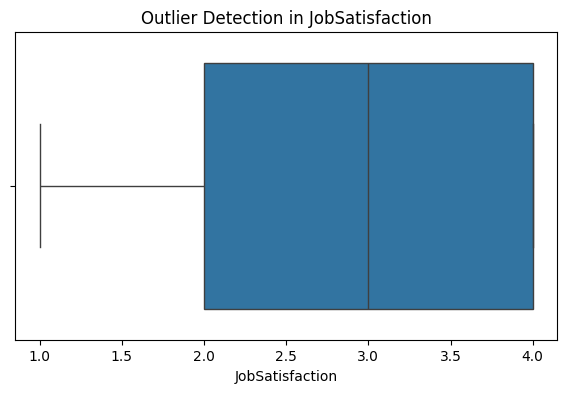

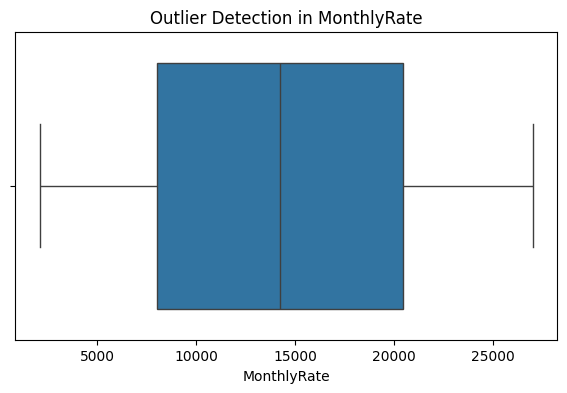

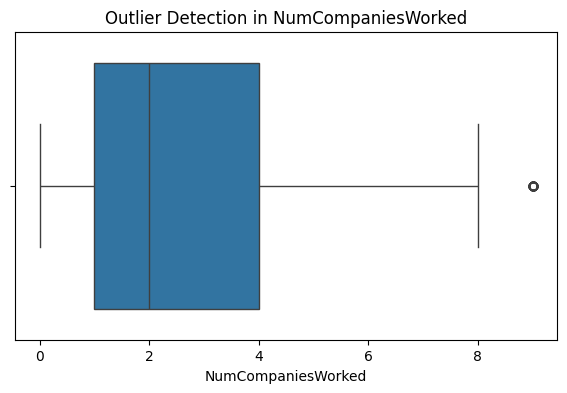

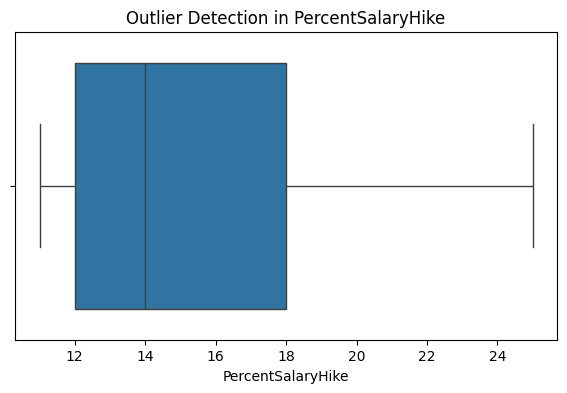

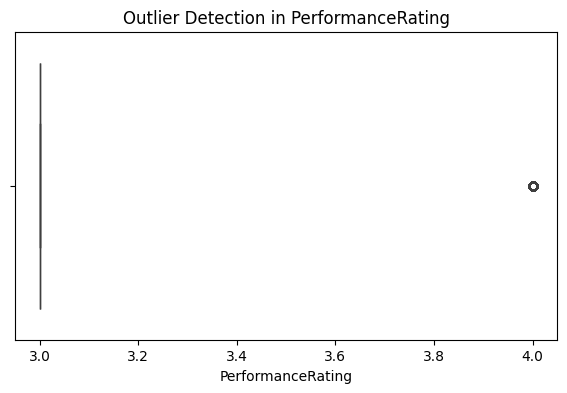

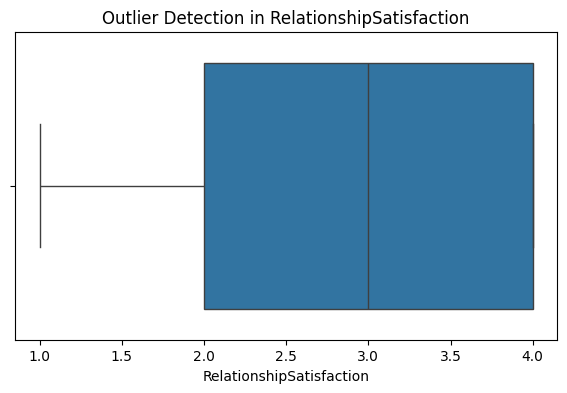

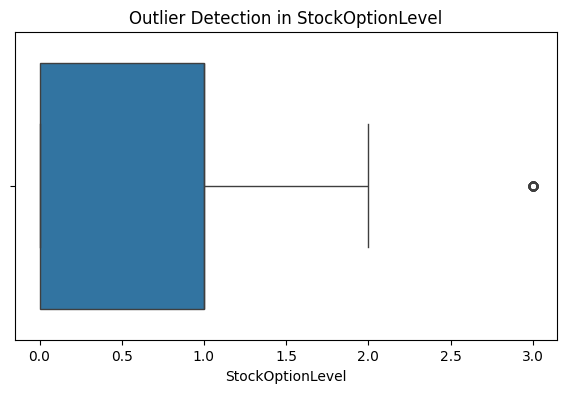

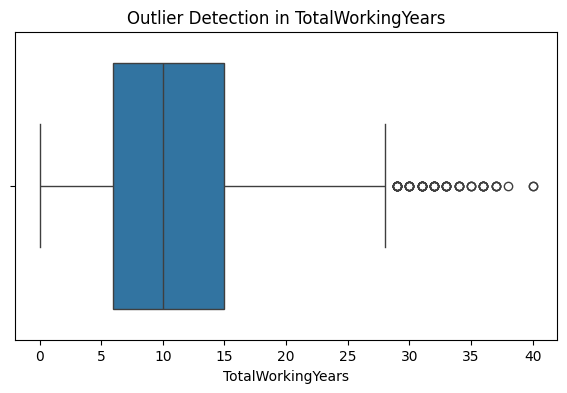

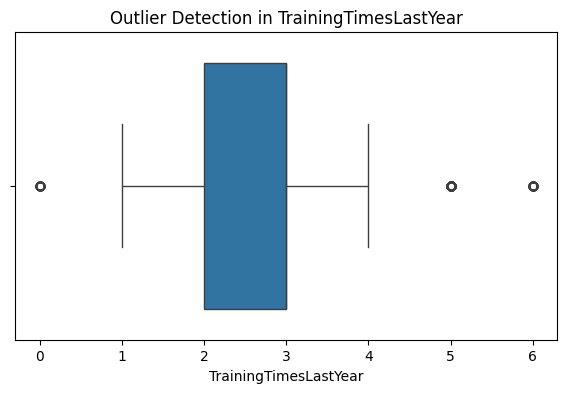

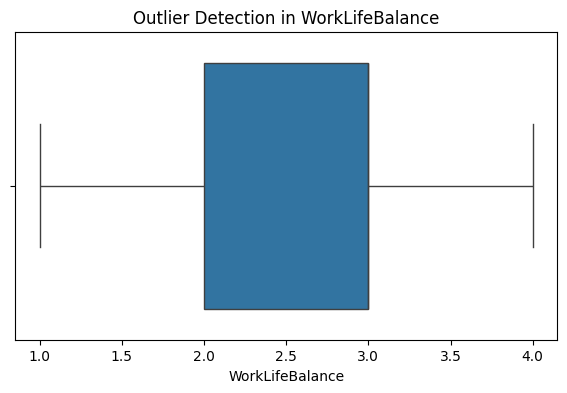

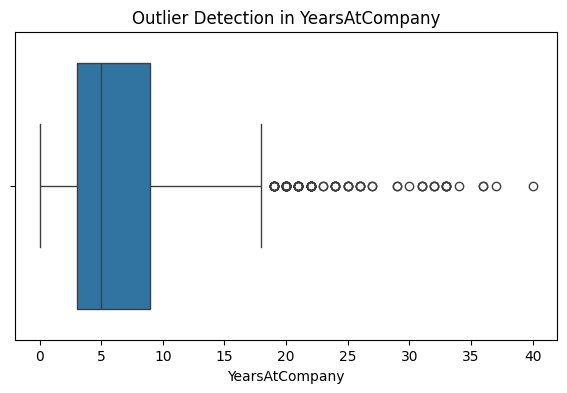

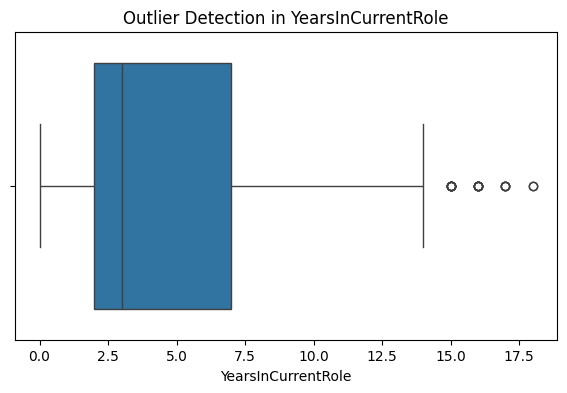

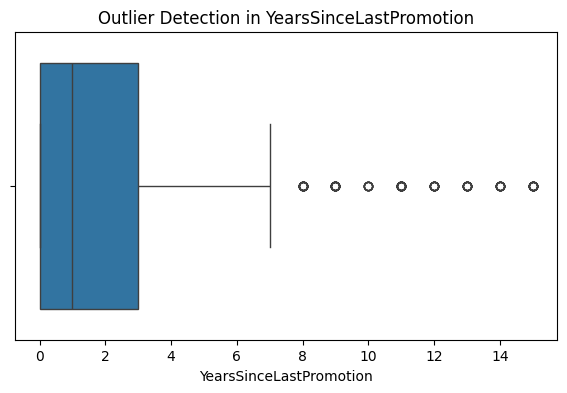

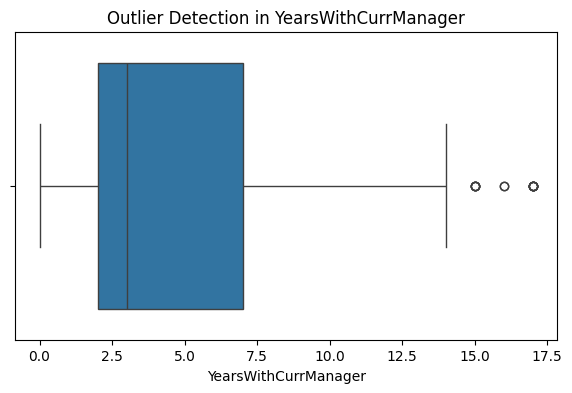

In [20]:
for col in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outlier Detection in {col}')
    plt.xlabel(col)
    plt.show()

In [21]:
def count_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]

    return len(outliers), lower_bound, upper_bound

In [22]:
outlier_summary = []

for col in numerical_features:
    outlier_count, lower_bound, upper_bound = count_outliers_iqr(df, col)
    outlier_summary.append({
        'Feature': col,
        'Outlier Count': outlier_count,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Outlier Count,Lower Bound,Upper Bound
0,Age,0,10.500,62.500
1,DailyRate,0,-573.000,2195.000
2,DistanceFromHome,0,-16.000,32.000
3,Education,0,-1.000,7.000
4,EnvironmentSatisfaction,0,-1.000,7.000
5,HourlyRate,0,-5.625,137.375
6,JobInvolvement,0,0.500,4.500
7,JobLevel,0,-2.000,6.000
8,JobSatisfaction,0,-1.000,7.000
9,MonthlyRate,0,-10574.750,39083.250


## Features Engineering



In [23]:
def create_age_group(age):
    if age < 30:
        return 'Young'
    elif age < 45:
        return 'Adult'
    elif age < 60:
        return 'Middle_Aged'
    else:
        return 'Senior'
df['AgeGroup'] = df['Age'].apply(create_age_group)
categorical_features.append('AgeGroup')
df[['Age', 'AgeGroup']].head(10)

,Age,AgeGroup
0,41,Adult
1,49,Middle_Aged
2,37,Adult
3,33,Adult
4,27,Young
5,32,Adult
6,59,Middle_Aged
7,30,Adult
8,38,Adult
9,36,Adult


In [24]:
df['AgeGroup'].value_counts()

,count
AgeGroup,
Adult,830
Young,326
Middle_Aged,309
Senior,5


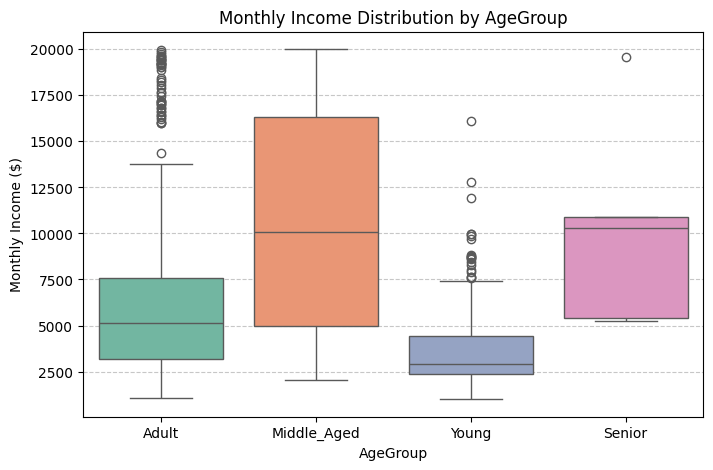

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='AgeGroup', y='MonthlyIncome', hue='AgeGroup', data=df, palette='Set2', legend=False)
plt.title('Monthly Income Distribution by AgeGroup')
plt.xlabel('AgeGroup')
plt.ylabel('Monthly Income ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [26]:
df["OverallSatisfaction"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"] +
    df["JobInvolvement"]
)
df["OverallSatisfaction"]

,OverallSatisfaction
0,10
1,11
2,11
3,13
4,10
...,...
1465,14
1466,8
1467,10
1468,12


In [27]:
df["CompanyTenureRatio"] = (df["YearsAtCompany"] /(df["TotalWorkingYears"] + 1))
df["CompanyTenureRatio"]

,CompanyTenureRatio
0,0.666667
1,0.909091
2,0.000000
3,0.888889
4,0.285714
...,...
1465,0.277778
1466,0.700000
1467,0.857143
1468,0.500000


In [28]:
df["PromotionDelayRatio"] = (df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1))
df["PromotionDelayRatio"]

,PromotionDelayRatio
0,0.000000
1,0.090909
2,0.000000
3,0.333333
4,0.666667
...,...
1465,0.000000
1466,0.125000
1467,0.000000
1468,0.000000


In [29]:
df["OverTime_WorkLife"] = ((df["OverTime"] == "Yes").astype(int) * df["WorkLifeBalance"])
df["OverTime_WorkLife"]

,OverTime_WorkLife
0,1
1,0
2,3
3,3
4,0
...,...
1465,0
1466,0
1467,3
1468,0


# Regression Problem

## Target Variable:
MonthlyIncome

In [30]:
X_reg = df.drop(["MonthlyIncome", "Attrition"], axis=1)
y_reg = df["MonthlyIncome"]

In [31]:
X_reg = pd.get_dummies(X_reg,drop_first=True)

In [32]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [33]:
scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)

## Linear Regression

In [34]:
lr = LinearRegression()

lr.fit(X_train_reg,y_train_reg)
lr_pred = lr.predict(X_test_reg)

In [35]:
lr_results = {
"MAE": mean_absolute_error(y_test_reg,lr_pred),
"MSE": mean_squared_error(y_test_reg,lr_pred),
"RMSE": np.sqrt(mean_squared_error(y_test_reg,lr_pred)),
"R2": r2_score(y_test_reg,lr_pred)
}

lr_results

{'MAE': 896.7392233785572,
 'MSE': 1387163.3997564875,
 'RMSE': np.float64(1177.7790114263744),
 'R2': 0.9365299720162066}

## Decision Tree Regressor

In [36]:
dtr = DecisionTreeRegressor(max_depth=6,random_state=42)

dtr.fit(X_train_reg,y_train_reg)
dtr_pred = dtr.predict(X_test_reg)

In [37]:
dtr_results = {
"MAE": mean_absolute_error(y_test_reg,dtr_pred),
"MSE": mean_squared_error(y_test_reg,dtr_pred),
"RMSE": np.sqrt(mean_squared_error(y_test_reg,dtr_pred)),
"R2": r2_score(y_test_reg,dtr_pred)
}

dtr_results

{'MAE': 826.3148230054447,
 'MSE': 1333722.5897286339,
 'RMSE': np.float64(1154.86907904257),
 'R2': 0.9389751704034621}

##CatBoost Regressor

In [38]:
cat = CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42)

cat.fit(X_train_reg,y_train_reg)

CatBoostRegressor(depth=6, iterations=300, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=0)

In [39]:
cat_results = {
    "MAE": mean_absolute_error(y_test_reg,cat.predict(X_test_reg)),
    "MSE": mean_squared_error(y_test_reg,cat.predict(X_test_reg)),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg,cat.predict(X_test_reg))),
    "R2": r2_score(y_test_reg,cat.predict(X_test_reg))
}

cat_results

{'MAE': 869.3563155860353,
 'MSE': 1342784.4808539595,
 'RMSE': np.float64(1158.7857786726413),
 'R2': 0.9385605411799608}

##LGBM Regressor

In [40]:
lgbm = LGBMRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)

lgbm.fit(X_train_reg, y_train_reg)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000736 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1125
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 49
[LightGBM] [Info] Start training from score 6382.523810
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LGBMRegressor(learning_rate=0.05, max_depth=5, n_estimators=150,
              random_state=42)

In [41]:
lgbm_results = {
    "MAE": mean_absolute_error(y_test_reg, lgbm.predict(X_test_reg)),
    "MSE": mean_squared_error(y_test_reg, lgbm.predict(X_test_reg)),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, lgbm.predict(X_test_reg))),
    "R2": r2_score(y_test_reg, lgbm.predict(X_test_reg))
}

lgbm_results

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


{'MAE': 845.2897915684373,
 'MSE': 1286708.672686094,
 'RMSE': np.float64(1134.3318177174147),
 'R2': 0.9411263046035437}

In [54]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# 1. Establish K-Fold Cross-Validation structure
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 2. Hyperparameter Tuning for Decision Tree Regressor using GridSearchCV
param_grid_xgb = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5],
}

grid_search_xgb = GridSearchCV(
    estimator = XGBRegressor(random_state=42),
    param_grid = param_grid_xgb,
    cv = kf,
    scoring = 'r2',
    n_jobs = -1
)

grid_search_xgb.fit(X_train_reg, y_train_reg)

grid_search_xgb_results = {
    "MAE": mean_absolute_error(y_test_reg, grid_search_xgb.predict(X_test_reg)),
    "MSE": mean_squared_error(y_test_reg, grid_search_xgb.predict(X_test_reg)),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, grid_search_xgb.predict(X_test_reg))),
    "R2": r2_score(y_test_reg, grid_search_xgb.predict(X_test_reg))
}

print(f"Best Decision Tree Regressor Params: {grid_search_xgb.best_params_}")
print(f"Best Decision Tree Regressor CV R2: {grid_search_xgb.best_score_:.4f}")

Best Decision Tree Regressor Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best Decision Tree Regressor CV R2: 0.9516


## Stacking

In [50]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

estimators = [
    ('rf', RandomForestRegressor(n_estimators=150, random_state=42)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
    ('gbdt',GradientBoostingRegressor()),
    ('svr', SVR(kernel='rbf'))
]

stack = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())

stack.fit(X_train_reg, y_train_reg)

stack_results = {
    "MAE": mean_absolute_error(y_test_reg, stack.predict(X_test_reg)),
    "MSE": mean_squared_error(y_test_reg, stack.predict(X_test_reg)),
    "RMSE": np.sqrt(mean_squared_error(y_test_reg, stack.predict(X_test_reg))),
    "R2": r2_score(y_test_reg, stack.predict(X_test_reg))
}

stack_results

{'MAE': 812.0121301875885,
 'MSE': 1213685.049537952,
 'RMSE': np.float64(1101.6737491371719),
 'R2': 0.9444675197808647}

# Regression Models Comparison

In [55]:
regression_results = pd.DataFrame(
    [
        lr_results,
        dtr_results,
        cat_results,
        lgbm_results,
        grid_search_xgb_results,
        stack_results
    ],

    index=[
        "Linear Regression",
        "Decision Tree Regressor",
        "CatBoost Regressor",
        "LightGBM Regressor",
        "Tunned XGBoost Regressor",
        "Stcking"
    ]
)

regression_results.sort_values("R2", ascending=True)
regression_results

,MAE,MSE,RMSE,R2
Linear Regression,896.739223,1.387163e+06,1177.779011,0.936530
Decision Tree Regressor,826.314823,1.333723e+06,1154.869079,0.938975
CatBoost Regressor,869.356316,1.342784e+06,1158.785779,0.938561
LightGBM Regressor,845.289792,1.286709e+06,1134.331818,0.941126
Tunned XGBoost Regressor,817.605896,1.215673e+06,1102.575508,0.944377
Stcking,812.012130,1.213685e+06,1101.673749,0.944468


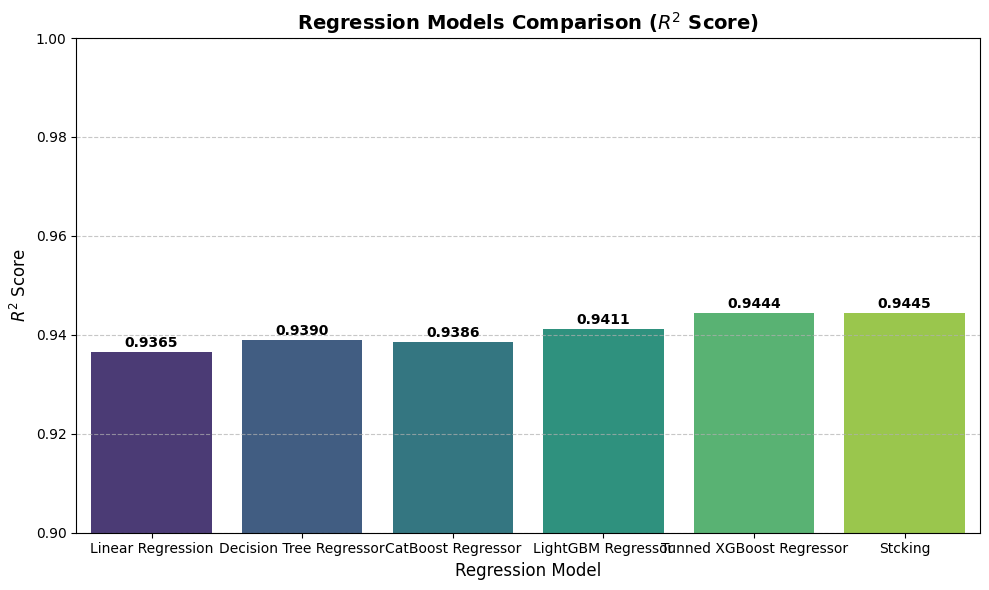

In [56]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x=regression_results.index,
    y=regression_results['R2'],
    hue=regression_results.index,
    palette='viridis',
    legend=False
)

plt.title('Regression Models Comparison ($R^2$ Score)', fontsize=14, fontweight='bold')
plt.xlabel('Regression Model', fontsize=12)
plt.ylabel('$R^2$ Score', fontsize=12)
plt.ylim(0.9, 1.0)  # Setting limits to highlight differences
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding values on top of the bars
for index, value in enumerate(regression_results['R2']):
    plt.text(index, value + 0.001, f"{value:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Classification Problem

## Target Variable:
Attrition

In [57]:
X_cls = df.drop("Attrition",axis=1)
y_cls = df["Attrition"]

In [58]:
X_cls = pd.get_dummies(X_cls, drop_first=True)

In [59]:
le = LabelEncoder()
y_cls = le.fit_transform(y_cls)

In [60]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls,y_cls, test_size=0.2, random_state=42, stratify=y_cls)

In [61]:
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

## Logistic Regression

In [62]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_cls_scaled, y_train_cls)
log_pred = log_model.predict(X_test_cls_scaled)

In [63]:
accuracy_score(y_test_cls, log_pred)

0.8571428571428571

## Decision Tree Classifier

In [68]:
dtc = DecisionTreeClassifier(max_depth=6, random_state=42)

dtc.fit(X_train_cls, y_train_cls)
dtc_pred = dtc.predict(X_test_cls)

In [69]:
accuracy_score(y_test_cls, dtc_pred)

0.7959183673469388

## CatBoost Classifier

In [72]:
cat = CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, verbose=0, random_state=42)

cat.fit(X_train_cls,y_train_cls)
cat_pred = cat.predict(X_test_cls)

In [73]:
accuracy_score(y_test_cls,cat_pred)

0.8605442176870748

## LightGBM Classifier

In [74]:
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)

lgbm.fit(X_train_cls, y_train_cls)
lgbm_pred = lgbm.predict(X_test_cls)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1343
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [75]:
accuracy_score(y_test_cls,lgbm_pred)

0.8639455782312925

# Classification Models Comparison

In [76]:
classification_results = pd.DataFrame(
{
   "Model" : [
      "Logistic Regression",
      "Decision Tree Classifier",
      "CatBoost",
      "LightGBM"
  ],

  "Accuracy": [
      accuracy_score(y_test_cls,log_pred),
      accuracy_score(y_test_cls,dtc_pred),
      accuracy_score(y_test_cls,cat_pred),
     accuracy_score(y_test_cls,lgbm_pred)
   ]
}
)

classification_results.sort_values("Accuracy", ascending=False)

,Model,Accuracy
3,LightGBM,0.863946
2,CatBoost,0.860544
0,Logistic Regression,0.857143
1,Decision Tree Classifier,0.795918


# Best Model Evaluation

In [77]:
print(classification_report(y_test_cls, lgbm_pred))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       247
           1       0.67      0.30      0.41        47

    accuracy                           0.86       294
   macro avg       0.77      0.63      0.67       294
weighted avg       0.85      0.86      0.84       294



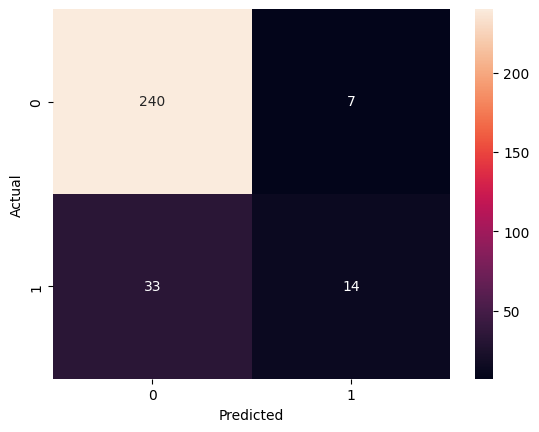

In [78]:
cm = confusion_matrix(y_test_cls,lgbm_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Classification Models Detailed Evaluation

In [80]:
models_predictions = {
    "Logistic Regression": log_pred,
    "Decision Tree": dtc_pred,
    "CatBoost": cat_pred,
    "LightGBM": lgbm_pred
}


evaluation = []


for name, pred in models_predictions.items():

    evaluation.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_cls,pred),
        "Precision": classification_report(
            y_test_cls,
            pred,
            output_dict=True
        )["1"]["precision"],
        "Recall": classification_report(
            y_test_cls,
            pred,
            output_dict=True
        )["1"]["recall"],
        "F1 Score": classification_report(
            y_test_cls,
            pred,
            output_dict=True
        )["1"]["f1-score"]
    })


classification_evaluation = pd.DataFrame(evaluation)
classification_evaluation.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.857143,0.592593,0.340426,0.432432
3,LightGBM,0.863946,0.666667,0.297872,0.411765
2,CatBoost,0.860544,0.714286,0.212766,0.327869
1,Decision Tree,0.795918,0.324324,0.255319,0.285714


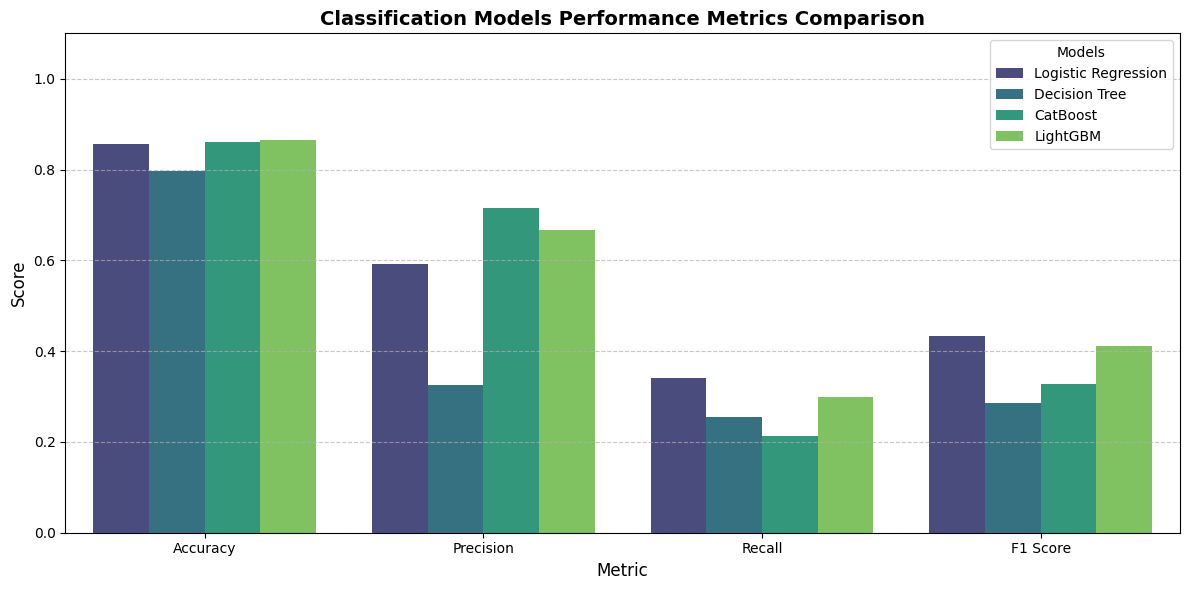

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the classification_evaluation dataframe for easy plotting with seaborn
melted_eval = pd.melt(
    classification_evaluation,
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x="Metric",
    y="Score",
    hue="Model",
    data=melted_eval,
    palette="viridis"
)

plt.title("Classification Models Performance Metrics Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(title="Models", loc="upper right")
plt.tight_layout()
plt.show()

# CatBoost Hyperparameter Tuning

In [82]:
cat_tuned = CatBoostClassifier(iterations=500, learning_rate=0.03, depth=5, l2_leaf_reg=5, loss_function="Logloss", verbose=0, random_state=42)

cat_tuned.fit(X_train_cls, y_train_cls)
cat_tuned_pred = cat_tuned.predict(X_test_cls)

In [83]:
print(classification_report(y_test_cls,cat_tuned_pred))
accuracy_score(y_test_cls,cat_tuned_pred)

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.67      0.21      0.32        47

    accuracy                           0.86       294
   macro avg       0.77      0.60      0.62       294
weighted avg       0.84      0.86      0.82       294



0.8571428571428571

# LightGBM Hyperparameter Tuning

In [84]:
lgbm_tuned = LGBMClassifier(n_estimators=200, learning_rate=0.03, num_leaves=20, max_depth=5, random_state=42)

lgbm_tuned.fit(X_train_cls, y_train_cls)
lgbm_tuned_pred = lgbm_tuned.predict(X_test_cls)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000304 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1343
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.161565 -> initscore=-1.646632
[LightGBM] [Info] Start training from score -1.646632
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [85]:
print(classification_report(y_test_cls,lgbm_tuned_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.70      0.30      0.42        47

    accuracy                           0.87       294
   macro avg       0.79      0.64      0.67       294
weighted avg       0.85      0.87      0.84       294



# ROC Curve Comparison

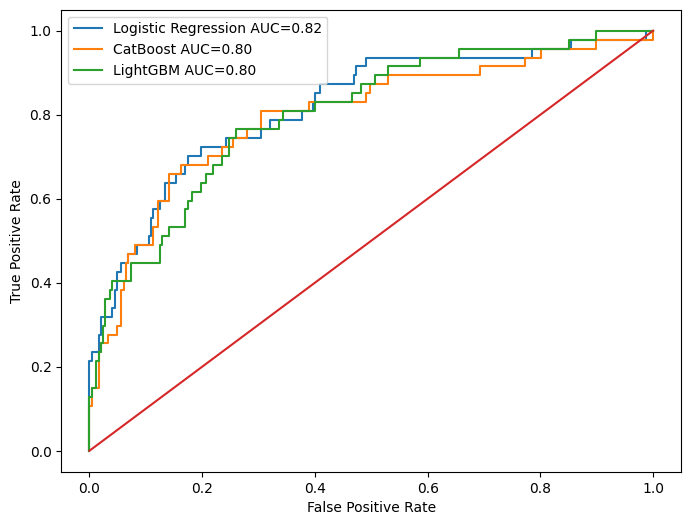

In [86]:
from sklearn.metrics import roc_curve, auc

models_prob = {
   "Logistic Regression" : log_model.predict_proba(X_test_cls_scaled)[:,1],
   "CatBoost" : cat.predict_proba(X_test_cls)[:,1],
   "LightGBM" : lgbm.predict_proba(X_test_cls)[:,1]
}

plt.figure(figsize=(8,6))
for name,prob in models_prob.items():
    fpr,tpr,_ = roc_curve(y_test_cls, prob)
    score = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name} AUC={score:.2f}")

plt.plot([0,1],[0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Feature Importance

In [87]:
importance = pd.DataFrame({
  "Feature": X_cls.columns,
  "Importance": lgbm.feature_importances_
})


importance.sort_values("Importance",ascending=False).head(15)

,Feature,Importance
9,MonthlyIncome,410
1,DailyRate,378
0,Age,276
5,HourlyRate,251
10,MonthlyRate,243
24,CompanyTenureRatio,238
2,DistanceFromHome,212
23,OverallSatisfaction,191
12,PercentSalaryHike,158
26,OverTime_WorkLife,156


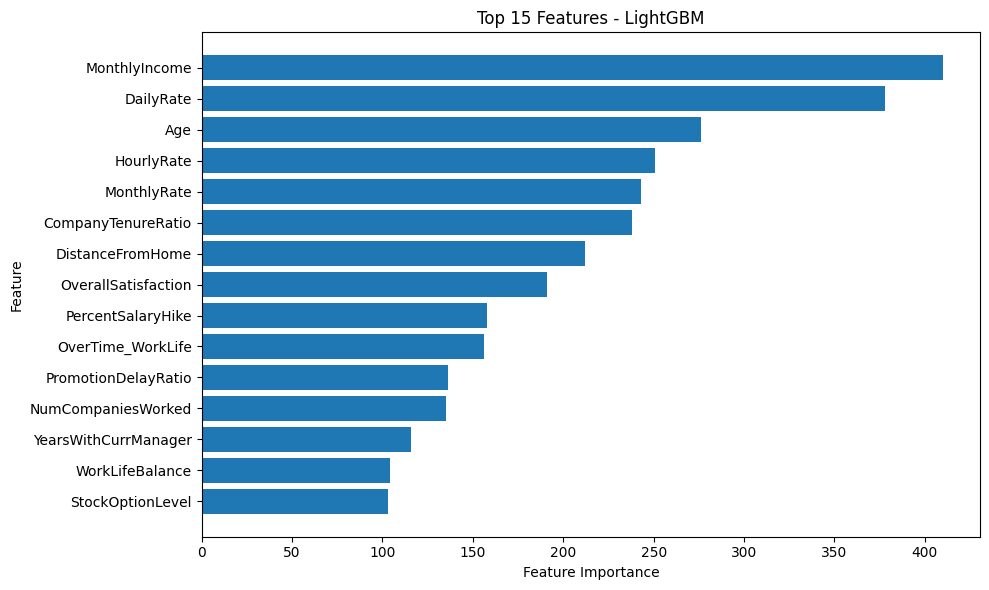

In [88]:
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X_cls.columns,
    "Importance": lgbm.feature_importances_
})

top = importance.sort_values("Importance",ascending=False).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top["Feature"][::-1],
    top["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - LightGBM")
plt.tight_layout()
plt.show()

# Handling Class Imbalance

In [89]:
pd.Series(y_train_cls).value_counts()

,count
0,986
1,190


## Logistic Regression with Class Weight

In [90]:
log_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_balanced.fit(X_train_cls_scaled, y_train_cls)

log_balanced_pred = log_balanced.predict(X_test_cls_scaled)

In [91]:
print(classification_report(y_test_cls,log_balanced_pred))

              precision    recall  f1-score   support

           0       0.92      0.79      0.85       247
           1       0.38      0.66      0.48        47

    accuracy                           0.77       294
   macro avg       0.65      0.73      0.67       294
weighted avg       0.84      0.77      0.79       294



## Decision Tree Classifier with Class Weight

In [92]:
dt_balanced = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(X_train_cls,y_train_cls)
dt_balanced_pred = dt_balanced.predict(X_test_cls)

In [93]:
print(classification_report(y_test_cls,dt_balanced_pred))

              precision    recall  f1-score   support

           0       0.92      0.81      0.86       247
           1       0.39      0.64      0.49        47

    accuracy                           0.79       294
   macro avg       0.66      0.73      0.68       294
weighted avg       0.84      0.79      0.80       294



## CatBoost with Class Weights

In [94]:
cat_balanced = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=5,
    class_weights=[1,4],
    verbose=0,
    random_state=42
)


cat_balanced.fit(X_train_cls, y_train_cls)
cat_balanced_pred = cat_balanced.predict(X_test_cls)

In [95]:
print(classification_report(y_test_cls,cat_balanced_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       247
           1       0.56      0.38      0.46        47

    accuracy                           0.85       294
   macro avg       0.73      0.66      0.69       294
weighted avg       0.84      0.85      0.84       294



## LightGBM with Class Weight

In [98]:
lgbm_balanced = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=20,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)


lgbm_balanced.fit(X_train_cls,y_train_cls)
lgbm_balanced_pred = lgbm_balanced.predict(X_test_cls)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 190, number of negative: 986
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1343
[LightGBM] [Info] Number of data points in the train set: 1176, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

In [99]:
print(classification_report(y_test_cls, lgbm_balanced_pred))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       247
           1       0.54      0.45      0.49        47

    accuracy                           0.85       294
   macro avg       0.72      0.69      0.70       294
weighted avg       0.84      0.85      0.84       294



# Final Classification Comparison

In [100]:
final_predictions = {
   "Logistic Balanced": log_balanced_pred,
   "Decision Tree Balanced": dt_balanced_pred,
   "CatBoost Balanced": cat_balanced_pred,
   "LightGBM Balanced": lgbm_balanced_pred
}

final_results=[]
for name,pred in final_predictions.items():
  report = classification_report(y_test_cls,pred,output_dict=True)
  final_results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test_cls, pred),
        "Precision":report["1"]["precision"],
        "Recall":report["1"]["recall"],
        "F1 Score":report["1"]["f1-score"]
    })

final_comparison = pd.DataFrame(final_results)
final_comparison.sort_values("F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
3,LightGBM Balanced,0.850340,0.538462,0.446809,0.488372
1,Decision Tree Balanced,0.785714,0.394737,0.638298,0.487805
0,Logistic Balanced,0.772109,0.378049,0.659574,0.480620
2,CatBoost Balanced,0.853741,0.562500,0.382979,0.455696


# ROC AUC Score Comparison

In [101]:
from sklearn.metrics import roc_auc_score

prob_models = {
   "Logistic Balanced":log_balanced.predict_proba(X_test_cls_scaled)[:,1],
   "CatBoost Balanced":cat_balanced.predict_proba(X_test_cls)[:,1],
   "LightGBM Balanced":lgbm_balanced.predict_proba(X_test_cls)[:,1]
}

auc_results=[]
for name,prob in prob_models.items():

    auc_results.append({
        "Model":name,
        "AUC":roc_auc_score(y_test_cls, prob)
    })


pd.DataFrame(auc_results).sort_values("AUC", ascending=False)

,Model,AUC
0,Logistic Balanced,0.806529
2,LightGBM Balanced,0.793264
1,CatBoost Balanced,0.784736


# CatBoost Threshold Optimization

In [102]:
from sklearn.metrics import f1_score

cat_prob = cat_balanced.predict_proba(X_test_cls)[:,1]
thresholds = np.arange(0.2, 0.7, 0.05)

threshold_results=[]
for t in thresholds:
    pred = (cat_prob >= t).astype(int)
    threshold_results.append({
        "Threshold":t,
        "Accuracy":accuracy_score(y_test_cls, pred),
        "Recall":classification_report(y_test_cls,pred,output_dict=True)["1"]["recall"],
        "F1":f1_score(y_test_cls,pred)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values("F1",ascending=False)

,Threshold,Accuracy,Recall,F1
2,0.30,0.826531,0.659574,0.548673
1,0.25,0.778912,0.680851,0.496124
3,0.35,0.819728,0.531915,0.485437
4,0.40,0.840136,0.468085,0.483516
5,0.45,0.853741,0.404255,0.469136
0,0.20,0.738095,0.723404,0.468966
6,0.50,0.853741,0.382979,0.455696
7,0.55,0.850340,0.340426,0.421053
8,0.60,0.857143,0.319149,0.416667
9,0.65,0.860544,0.255319,0.369231


# Final Model Training and Saving

The best performing model will be trained using the complete dataset and saved for deployment.

In [103]:
import joblib

In [104]:
X_final = X_cls.copy()
y_final = y_cls.copy()

In [105]:
final_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=5,
    class_weights=[1,4],
    verbose=0,
    random_state=42
)


final_model.fit(X_final,y_final)

CatBoostClassifier(class_weights=[1, 4], depth=5, iterations=500, learning_rate=0.03, random_state=42, verbose=0)

In [106]:
joblib.dump(final_model,"employee_attrition_catboost_model.pkl")

['employee_attrition_catboost_model.pkl']

In [107]:
joblib.dump(X_final.columns.tolist(), "employee_features.pkl")

['employee_features.pkl']

In [109]:
loaded_model = joblib.load("employee_attrition_catboost_model.pkl")

loaded_features = joblib.load("employee_features.pkl")

# Final Model Information

In [110]:
print("Model: CatBoost Classifier")
print("Iterations:", final_model.tree_count_)
print("Number of Features:", len(loaded_features))

Model: CatBoost Classifier
Iterations: 500
Number of Features: 51
